In [82]:
import numpy as np
import pygimli as pg
from pygimli.physics import ert

In [83]:
# data3d = ert.load("slagdump3d.ohm")
data3d = pg.getExampleData("ert/slagdump3d.ohm", verbose=True)
print(data3d)

01/10/25 - 19:05:33 - pyGIMLi - INFO - Looking for ert/slagdump3d.ohm in gimli-org/example-data/
01/10/25 - 19:05:33 - pyGIMLi - INFO - File already exists: C:\Users\Thomas Guenther\AppData\Roaming\pygimli\Cache\example-data\gimli-org/example-data/master\ert/slagdump3d.ohm
01/10/25 - 19:05:33 - pyGIMLi - INFO - Reading C:\Users\Thomas Guenther\AppData\Roaming\pygimli\Cache\example-data\gimli-org/example-data/master\ert/slagdump3d.ohm (<class 'pgcore._pygimli_.DataContainerERT'>)


Data: Sensors: 577 data: 4245, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']


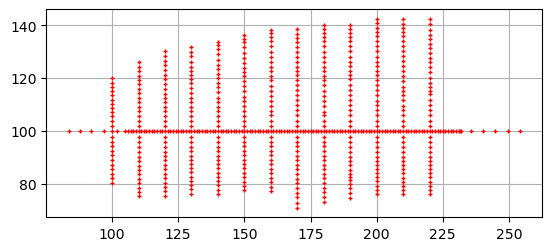

In [84]:
pg.plt.plot(pg.x(data3d), pg.y(data3d), 'r+');
pg.plt.gca().set_aspect(1.0)
pg.plt.grid();

In [85]:
def data3Dto2D(data):
    """Convert 3D ERT data to 2D by projecting onto a plane.

    Parameters
    ----------
    data : pg.DataContainerERT
        3D ERT data container.

    Returns
    -------
    pg.DataContainer
        2D data container.
    pos : ndarray
        interpolation 
    """
    # data2d = data.copy()
    xe = pg.x(data)
    ye = pg.y(data)
    ze = pg.z(data)
    xnew = np.hstack([0., np.cumsum(np.sqrt(np.diff(xe)**2 + np.diff(ye)**2))])
    txy = np.column_stack((xe, ye))
    data.setSensors(np.column_stack((xnew, ze)))
    return data, txy

In [86]:
def model2Dto3D(mesh, xy):
    """Convert 2D model to 3D by interpolation.

    Parameters
    ----------
    model2d : pg.Vector
        2D model vector.
    txy : ndarray
        interpolation table.

    Returns
    -------
    rotated mesh
    """
    mt = pg.x(mesh)
    mz = pg.y(mesh)
    xy = np.asarray(xy)
    tapex = np.hstack([0., np.cumsum(np.sqrt(np.sum(np.diff(xy, axis=0)**2, axis=1)))])
    mx = np.interp(mt, tapex, xy[:, 0])
    my = np.interp(mt, tapex, xy[:, 1])
    out = mesh.copy()
    out.setDimension(3)
    for i, node in enumerate(out.nodes()):
        node.setPos([mx[i], my[i], mz[i]])
    return out

In [87]:
dataX150, xyX150 = data3Dto2D(data3d.subset(x=150))
print(dataX150)

Data: Sensors: 34 data: 173, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid', 'xa', 'xb', 'xm', 'xn']


In [88]:
dataX150.createGeometricFactors(numerical=True)
dataX150["rhoa"] = dataX150["r"] * dataX150["k"]
dataX150.ensure2D()

01/10/25 - 19:05:34 - pyGIMLi - INFO - Cache c:\src\gimli\gimli\pygimli\physics\ert\ert.py:createGeometricFactors restored (2.2s x 5): C:\Users\Thomas Guenther\AppData\Roaming\pygimli\Cache\18062828236322244075


In [97]:
dataX150.estimateError()
mgr = ert.Manager(dataX150)
mgr.invert(verbose=True)

01/10/25 - 19:08:17 - pyGIMLi - INFO - Found 2 regions.
01/10/25 - 19:08:17 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/10/25 - 19:08:17 - pyGIMLi - INFO - Found 2 regions.
01/10/25 - 19:08:17 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/10/25 - 19:08:17 - pyGIMLi - INFO - Creating forward mesh from region infos.
01/10/25 - 19:08:17 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
01/10/25 - 19:08:17 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1371 Cells: 2560 Boundaries: 2010
01/10/25 - 19:08:17 - pyGIMLi - INFO - Use median(data values)=12.494764213410708
01/10/25 - 19:08:17 - pyGIMLi - INFO - Created startmodel from forward operator:501, min/max=12.494764/12.494764
01/10/25 - 19:08:17 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001B424F2E7F0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 6.32/66.08
min/max (error): 3%/3%
min/max (start model): 12.49/12.49
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  356.08
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   27.53 (dPhi = 90.67%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    2.52 (dPhi = 71.75%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.15 (dPhi = 1.64%) lam: 20.0
################################################################################
#                Abort criterion reached: dPhi = 1.64 (< 2.0%)                 #
##########################

501 [141.2334685439435,...,6.41064938836943]

In [98]:
bla = mgr.paraDomain
bla.boundingBox()

BoundingBox [RVector3: (-3.9994499621822963, 84.97999999999999, 0.0), RVector3: (62.79944996218231, 121.33, 0.0)]

In [99]:
outX150 = model2Dto3D(mgr.paraDomain, xyX150)
outX150["res"] = mgr.paraModel()
# pg.show(outX150, "res", logScale=True, cMap="jet", label="Resistivity (Ohm.m)")

In [92]:
dataY100, xyY100 = data3Dto2D(data3d.subset(y=100))
dataY100.createGeometricFactors(numerical=True)
dataY100["rhoa"] = dataY100["r"] * dataY100["k"]
dataY100.ensure2D()
dataY100.estimateError()
mgr = ert.Manager(dataY100)
mgr.invert(verbose=True)

01/10/25 - 19:05:40 - pyGIMLi - INFO - Cache c:\src\gimli\gimli\pygimli\physics\ert\ert.py:createGeometricFactors restored (16.3s x 4): C:\Users\Thomas Guenther\AppData\Roaming\pygimli\Cache\17566380879500315371
01/10/25 - 19:05:40 - pyGIMLi - INFO - Found 2 regions.
01/10/25 - 19:05:40 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/10/25 - 19:05:40 - pyGIMLi - INFO - Found 2 regions.
01/10/25 - 19:05:40 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/10/25 - 19:05:40 - pyGIMLi - INFO - Creating forward mesh from region infos.
01/10/25 - 19:05:40 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
01/10/25 - 19:05:40 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 5159 Cells: 9688 Boundaries: 7580
01/10/25 - 19:05:40 - pyGIMLi - INFO - Use median(data values)=13.032969552720283
01/10/25 - 19:05:40 - pyGIMLi - INFO - Created startmodel from forward operator:2208, min/max=13.032970/13.032970
01/10/25 -

fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001B42F6CFDD0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 6.66/211
min/max (error): 3%/3%
min/max (start model): 13.03/13.03
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  484.15
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   39.48 (dPhi = 91.27%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   10.26 (dPhi = 70.92%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    9.81 (dPhi = 2.48%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    9.79 (dPhi = 0.46%) lam: 20.0
######################################################

2208 [23.53237050425636,...,15.978439809058912]

In [93]:
outY100 = model2Dto3D(mgr.paraDomain, xyY100)
outY100["res"] = mgr.paraModel()

In [102]:
kw = dict(cMin=4, cMax=40, logScale=True, cMap="Spectral_r")
pl, _ = pg.show(outX150, "res", hold=True, **kw)
pg.show(outY100, "res", ax=pl, **kw)

Widget(value='<iframe src="http://localhost:50975/index.html?ui=P_0x1b3f64ca390_23&reconnect=auto" class="pyvi…

(<pyvista.plotting.plotter.Plotter at 0x1b3f64ca390>, None)